In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df=pd.read_csv("./global_superstore_2016(Orders).csv", encoding="latin1")

In [20]:
dupl=df.duplicated().sum()
print(dupl)
print("Mising values :")
print(df.isna().sum())

0
Mising values :
Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
Postal Code       41296
City                  0
State                 0
Country               0
Region                0
Market                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64


In [21]:
df.drop(columns=["Postal Code"])

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11-11-2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,Oklahoma City,Oklahoma,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,$221.98,2,0.0,$62.15,40.770,High
1,26341,IN-2014-JR162107-41675,02-05-2014,02-07-2014,Second Class,JR-162107,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black","$3,709.40",9,0.1,-$288.77,923.630,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID","$5,175.17",9,0.1,$919.97,915.490,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless","$2,892.51",5,0.1,-$96.54,910.160,Medium
4,47221,SG-2014-RH9495111-41948,11-05-2014,11-06-2014,Same Day,RH-9495111,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed","$2,832.96",8,0.0,$311.52,903.040,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,29002,IN-2015-KE1642066-42174,6/19/2015,6/19/2015,Same Day,KE-1642066,Katrina Edelman,Corporate,Kure,Hiroshima,...,OFF-FA-3072,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",$65.10,5,0.0,$4.50,1.010,Medium
51286,34337,US-2014-ZD21925140-41765,05-06-2014,05-10-2014,Standard Class,ZD-219251408,Zuschuss Donatelli,Consumer,Chattanooga,Tennessee,...,FUR-FU-4070,Furniture,Furnishings,"Eldon Image Series Desk Accessories, Burgundy",$16.72,5,0.2,$3.34,1.930,High
51287,31315,CA-2012-ZD21925140-41147,8/26/2012,8/31/2012,Second Class,ZD-219251404,Zuschuss Donatelli,Consumer,San Francisco,California,...,OFF-AR-5321,Office Supplies,Art,Newell 341,$8.56,2,0.0,$2.48,1.580,High
51288,9596,MX-2013-RB1979518-41322,2/17/2013,2/21/2013,Standard Class,RB-1979518,Ross Baird,Home Office,Valinhos,SÃ£o Paulo,...,OFF-BI-2919,Office Supplies,Binders,"Acco Index Tab, Economy",$13.44,2,0.0,$2.40,1.003,Medium


In [23]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   Postal Code     9994 non-null   float64
 9   City            51290 non-null  object 
 10  State           51290 non-null  object 
 11  Country         51290 non-null  object 
 12  Region          51290 non-null  object 
 13  Market          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [24]:
if df["Sales"].dtype == object:
  df["Sales"] = (
      df["Sales"]
      .astype(str)
      .str.replace("$", "", regex=False)
      .str.replace(",", "", regex=False)
      .astype(float)
  )

In [25]:
category_revenue = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
category_revenue.columns = ["Category", "Total Revenue"]

In [26]:
category_revenue["Total Revenue Formatted"] = category_revenue[
    "Total Revenue"
].apply(lambda x: f"${x:,.2f}")
print(category_revenue)

          Category  Total Revenue Total Revenue Formatted
0       Technology     4744558.76           $4,744,558.76
1        Furniture     4110453.03           $4,110,453.03
2  Office Supplies     3787495.46           $3,787,495.46


In [27]:
df_sorted = df.sort_values(by=["Category", "Sales"], ascending=[True, False])

In [34]:
print(df_sorted[["Category", "Sales"]].head(5))

    Category    Sales
0  Furniture  5759.96
1  Furniture  5729.35
2  Furniture  5667.87
3  Furniture  5486.67
4  Furniture  5451.30


In [29]:
df_sorted = df_sorted.reset_index(drop=True)

print(df_sorted[["Category", "Sub-Category", "Sales", "Country"]].head(10))

    Category Sub-Category    Sales         Country
0  Furniture       Chairs  5759.96       Australia
1  Furniture       Chairs  5729.35          France
2  Furniture    Bookcases  5667.87           India
3  Furniture    Bookcases  5486.67       Australia
4  Furniture       Tables  5451.30  United Kingdom
5  Furniture       Tables  5451.30           India
6  Furniture       Tables  5244.84     New Zealand
7  Furniture       Chairs  5049.00           China
8  Furniture       Tables  4626.15     Afghanistan
9  Furniture       Chairs  4544.10          France


In [35]:
for col in ['Sales', 'Profit', 'Shipping Cost']:
  if df[col].dtype == object:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [36]:
for col in ['Quantity', 'Discount']:
  df[col] = pd.to_numeric(df[col], errors='coerce')

In [37]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']
corr_matrix = df[num_cols].corr()
print(corr_matrix.round(3))

               Sales  Quantity  Discount  Profit  Shipping Cost
Sales          1.000     0.314    -0.087   0.485          0.768
Quantity       0.314     1.000    -0.020   0.104          0.272
Discount      -0.087    -0.020     1.000  -0.316         -0.078
Profit         0.485     0.104    -0.316   1.000          0.354
Shipping Cost  0.768     0.272    -0.078   0.354          1.000


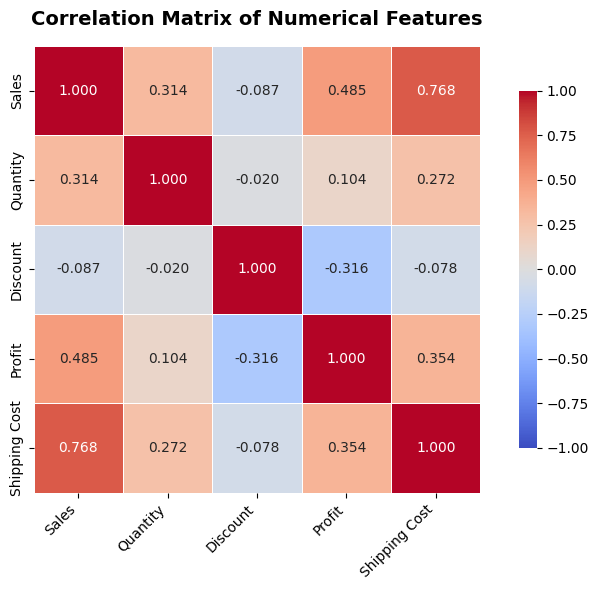

In [42]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
)
plt.title(
    'Correlation Matrix of Numerical Features',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()